In [7]:
import sys
sys.path.append(r"C:\Users\SUMANT\Desktop\youtube_etl_pipeline")
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sqlalchemy import create_engine
from config import DB_CONFIG

engine = create_engine(
    f"postgresql://{DB_CONFIG['user']}:{DB_CONFIG['password']}"
    f"@{DB_CONFIG['host']}:{DB_CONFIG['port']}/{DB_CONFIG['database']}"
)

df = pd.read_sql("SELECT * FROM trending_videos", engine)
print(f"Total records: {len(df):,}")
print(f"Unique videos: {df['video_id'].nunique():,}")
print(f"Date range: {df['extracted_at'].min()} → {df['extracted_at'].max()}")


Total records: 218
Unique videos: 218
Date range: 2026-05-08 09:12:26.774205 → 2026-05-08 11:07:34.585463


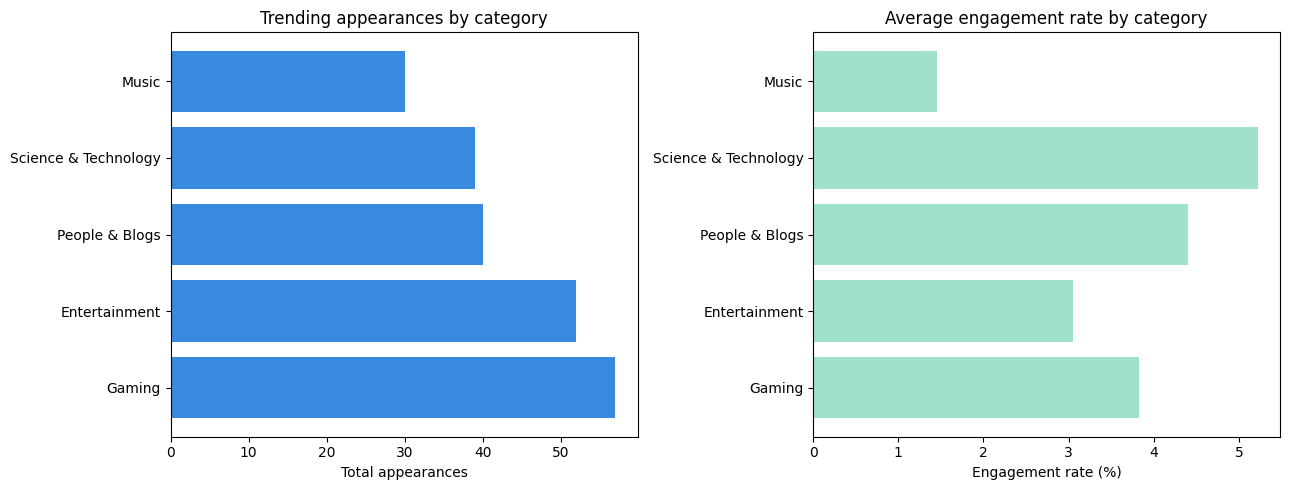

                      total_appearances   avg_views  avg_engagement  \
category_name                                                         
Gaming                               57   472671.51            3.82   
Entertainment                        52  5904253.31            3.05   
People & Blogs                       40   418595.08            4.40   
Science & Technology                 39  1140497.08            5.22   
Music                                30  4472835.77            1.46   

                      avg_duration_mins  
category_name                            
Gaming                            79.79  
Entertainment                      0.78  
People & Blogs                    17.86  
Science & Technology               8.97  
Music                              4.68  


In [8]:
cat_stats = (df.groupby("category_name")
             .agg(
                 total_appearances = ("video_id","count"),
                 avg_views         = ("view_count","mean"),
                 avg_engagement    = ("engagement_rate","mean"),
                 avg_duration_mins = ("duration_minutes","mean")
             )
             .round(2)
             .sort_values("total_appearances", ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].barh(cat_stats.index, cat_stats["total_appearances"],
             color="#378ADD")
axes[0].set_title("Trending appearances by category")
axes[0].set_xlabel("Total appearances")

axes[1].barh(cat_stats.index, cat_stats["avg_engagement"],
             color="#9FE1CB")
axes[1].set_title("Average engagement rate by category")
axes[1].set_xlabel("Engagement rate (%)")
plt.tight_layout()
plt.savefig("category_analysis.png", dpi=150)
plt.show()
print(cat_stats)


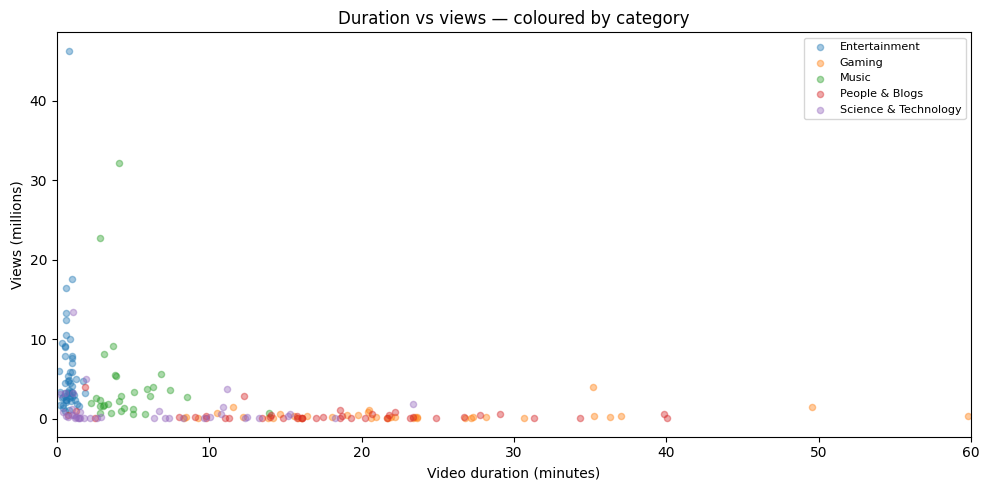

Entertainment: correlation = -0.052
Gaming: correlation = 0.144
Music: correlation = -0.148
People & Blogs: correlation = -0.295
Science & Technology: correlation = -0.057


In [9]:
fig, ax = plt.subplots(figsize=(10, 5))
for cat, grp in df.groupby("category_name"):
    ax.scatter(grp["duration_minutes"], grp["view_count"]/1e6,
               alpha=0.4, label=cat, s=20)

ax.set_xlabel("Video duration (minutes)")
ax.set_ylabel("Views (millions)")
ax.set_title("Duration vs views — coloured by category")
ax.legend(fontsize=8)
ax.set_xlim(0, 60)
plt.tight_layout()
plt.savefig("duration_vs_views.png", dpi=150)
plt.show()

# correlation per category
for cat, grp in df.groupby("category_name"):
    corr = grp["duration_minutes"].corr(grp["view_count"])
    print(f"{cat}: correlation = {corr:.3f}")


TOP 10% vs REST — title patterns:
Avg title length  — Top: 66.1 | Rest: 63.6
Avg word count    — Top: 9.4 | Rest: 11.2
Has numbers (%)   — Top: 31.8% | Rest: 41.3%


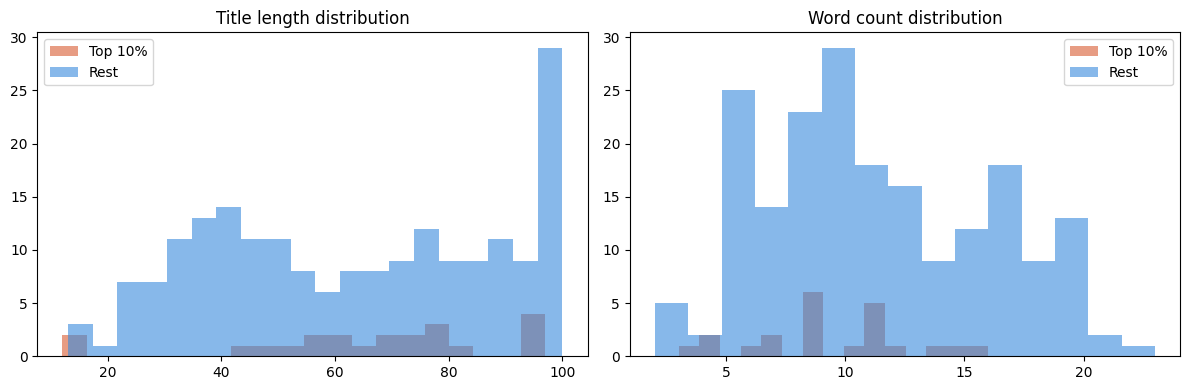

In [10]:
top_10pct = df[df["view_count"] >= df["view_count"].quantile(0.90)]
rest      = df[df["view_count"] <  df["view_count"].quantile(0.90)]

print("TOP 10% vs REST — title patterns:")
print(f"Avg title length  — Top: {top_10pct['title_length'].mean():.1f} "
      f"| Rest: {rest['title_length'].mean():.1f}")
print(f"Avg word count    — Top: {top_10pct['title_word_count'].mean():.1f} "
      f"| Rest: {rest['title_word_count'].mean():.1f}")
print(f"Has numbers (%)   — Top: {top_10pct['has_numbers'].mean():.1%} "
      f"| Rest: {rest['has_numbers'].mean():.1%}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(top_10pct["title_length"], bins=20,
             alpha=0.6, label="Top 10%", color="#D85A30")
axes[0].hist(rest["title_length"],      bins=20,
             alpha=0.6, label="Rest",    color="#378ADD")
axes[0].set_title("Title length distribution")
axes[0].legend()

axes[1].hist(top_10pct["title_word_count"], bins=15,
             alpha=0.6, label="Top 10%", color="#D85A30")
axes[1].hist(rest["title_word_count"],      bins=15,
             alpha=0.6, label="Rest",    color="#378ADD")
axes[1].set_title("Word count distribution")
axes[1].legend()
plt.tight_layout()
plt.savefig("title_patterns.png", dpi=150)
plt.show()


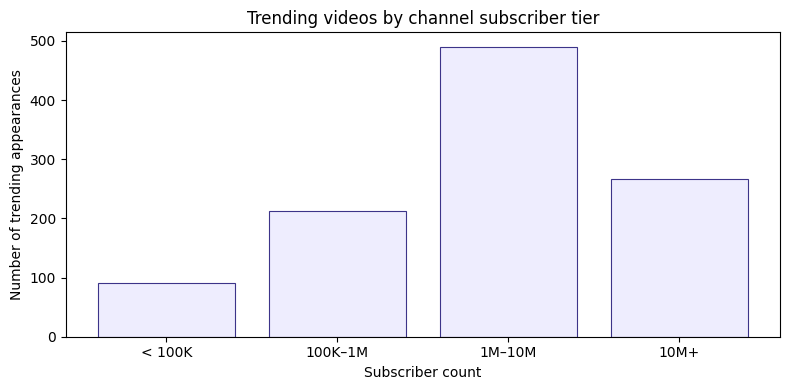

                 video_count   avg_views  avg_engagement
subscriber_tier                                         
< 100K                    90  1838001.56            0.93
100K–1M                  212   444809.38            4.03
1M–10M                   490  2029513.48            4.03
10M+                     267  5174764.01            3.69


In [11]:
ch_df = pd.read_sql("SELECT * FROM channel_stats", engine)
merged = df.merge(ch_df, on="channel_id", how="left")

bins   = [0, 100_000, 1_000_000, 10_000_000, float("inf")]
labels = ["< 100K", "100K–1M", "1M–10M", "10M+"]
merged["subscriber_tier"] = pd.cut(
    merged["subscriber_count"], bins=bins, labels=labels
)

tier_stats = (merged.groupby("subscriber_tier")
              .agg(video_count  = ("video_id","count"),
                   avg_views    = ("view_count","mean"),
                   avg_engagement = ("engagement_rate","mean"))
              .round(2))

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(tier_stats.index.astype(str),
       tier_stats["video_count"], color="#EEEDFE",
       edgecolor="#3C3489", linewidth=0.8)
ax.set_title("Trending videos by channel subscriber tier")
ax.set_xlabel("Subscriber count")
ax.set_ylabel("Number of trending appearances")
plt.tight_layout()
plt.savefig("channel_size_analysis.png", dpi=150)
plt.show()
print(tier_stats)

Total runs      : 30
Success rate    : 100.0%
Total inserted  : 1,027
Total skipped   : 206


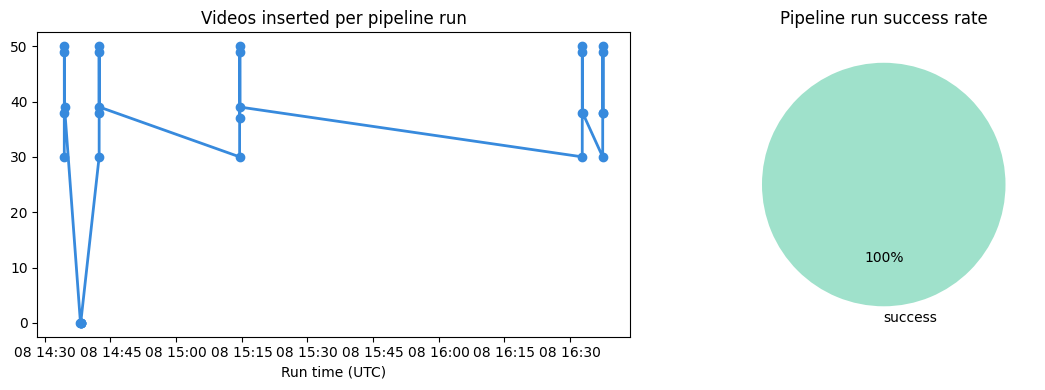

In [12]:
runs = pd.read_sql(
    "SELECT * FROM pipeline_runs ORDER BY run_at", engine
)
runs["run_at"] = pd.to_datetime(runs["run_at"])

print(f"Total runs      : {len(runs)}")
print(f"Success rate    : {(runs['status']=='success').mean():.1%}")
print(f"Total inserted  : {runs['videos_inserted'].sum():,}")
print(f"Total skipped   : {runs['videos_skipped'].sum():,}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(runs["run_at"], runs["videos_inserted"],
             marker="o", color="#378ADD", linewidth=2)
axes[0].set_title("Videos inserted per pipeline run")
axes[0].set_xlabel("Run time (UTC)")

status_counts = runs["status"].value_counts()
axes[1].pie(status_counts,
            labels   = status_counts.index,
            colors   = ["#9FE1CB","#F4A261"],
            autopct  = "%1.0f%%",
            startangle = 90)
axes[1].set_title("Pipeline run success rate")
plt.tight_layout()
plt.savefig("pipeline_health.png", dpi=150)
plt.show()
